In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from itertools import product
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [15]:
import os
DATA_PATH = os.environ.get(
    "MONETARY_DATA_PATH", os.path.join("..", "data", "Monetary_transmission_data_III.xlsx")
)
FEATURE_COLS = ["CPI", "EXR", "M2b", "RSV", "BRNT"]
TARGET_COLS = ["CPI", "EXR"]
WINDOW_SIZE = 12
FORECAST_HORIZON = 6
N_SPLITS = 5
TRAIN_RATIO = 0.85
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

PARAM_GRID = {
    "units": [32, 64],
    "layers": [1, 2],
    "dropout": [0.1, 0.2],
    "learning_rate": [1e-3, 5e-4],
    "batch_size": [16, 32],
}

In [16]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw Excel data and enforce a sorted monthly DatetimeIndex."""
    df = pd.read_excel(path, parse_dates=["DATE"])
    return df.sort_values("DATE").set_index("DATE")


df = load_data(DATA_PATH)[FEATURE_COLS]
df.head()

,CPI,EXR,M2b,RSV,BRNT
DATE,,,,,
2003-01-01,49.718237,96.76790,629492.928632,2.180175e+09,30.808696
2003-02-01,49.166690,96.86147,635737.068991,2.231537e+09,32.662500
2003-03-01,48.031996,96.93052,643063.430052,2.185916e+09,30.168095
2003-04-01,47.648499,96.98083,648591.184385,2.401949e+09,25.035000
2003-05-01,48.783192,97.21280,651250.316110,2.370521e+09,25.714545


In [17]:
# Structural-break dates partition the sample into four regimes; "Full" retains
# the entire series as a fifth, unsegmented baseline for comparison.
BREAK_DATES = pd.to_datetime(["2008-06-01", "2016-10-01", "2022-03-01"])
EDGES = [df.index.min(), *BREAK_DATES, df.index.max() + pd.DateOffset(days=1)]

WINDOWS = {
    f"W{i + 1}_{EDGES[i]:%Y%m}_{(EDGES[i + 1] - pd.DateOffset(days=1)):%Y%m}":
        (EDGES[i], EDGES[i + 1] - pd.DateOffset(days=1))
    for i in range(len(EDGES) - 1)
}
WINDOWS["Full_" + f"{df.index.min():%Y%m}_{df.index.max():%Y%m}"] = (df.index.min(), df.index.max())

for label, (start, end) in WINDOWS.items():
    print(f"{label}: {start.date()} -> {end.date()} ({len(df.loc[start:end])} months)")

W1_200301_200805: 2003-01-01 -> 2008-05-31 (65 months)
W2_200806_201609: 2008-06-01 -> 2016-09-30 (100 months)
W3_201610_202202: 2016-10-01 -> 2022-02-28 (65 months)
W4_202203_202510: 2022-03-01 -> 2025-10-01 (44 months)
Full_200301_202510: 2003-01-01 -> 2025-10-01 (274 months)


In [18]:
def scale_data(df_window: pd.DataFrame, feature_cols: list, target_cols: list) -> tuple:
    """Fit independent scalers for model inputs and forecast targets, local to one window."""
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(df_window[feature_cols])
    y_scaled = scaler_y.fit_transform(df_window[target_cols])
    return X_scaled, y_scaled, scaler_X, scaler_y


def create_sequences(X: np.ndarray, y: np.ndarray, window_size: int) -> tuple:
    """Convert scaled arrays into overlapping (lookback -> next-step) samples for the LSTM."""
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)


def safe_n_splits(n_samples: int, desired: int = N_SPLITS) -> int:
    """Cap TimeSeriesSplit folds so every fold receives at least one validation sample."""
    return max(2, min(desired, n_samples - 1))


def build_model(window_size: int, n_features: int, n_targets: int,
                 units: int = 64, layers: int = 1, dropout: float = 0.2,
                 learning_rate: float = 1e-3) -> Sequential:
    """Build a stacked LSTM regressor with configurable width, depth, dropout, and learning rate."""
    model = Sequential()
    for i in range(layers):
        return_sequences = i < layers - 1
        kwargs = {"input_shape": (window_size, n_features)} if i == 0 else {}
        model.add(LSTM(units, return_sequences=return_sequences, **kwargs))
        model.add(Dropout(dropout))
    model.add(Dense(n_targets))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model


def rolling_window_validation(X: np.ndarray, y: np.ndarray, params: dict,
                               n_splits: int, epochs: int = 50) -> float:
    """Walk-forward validation: fit on each expanding window, score on the following block."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_scores = []
    for train_idx, val_idx in tscv.split(X):
        model = build_model(
            window_size=X.shape[1], n_features=X.shape[2], n_targets=y.shape[1],
            units=params["units"], layers=params["layers"],
            dropout=params["dropout"], learning_rate=params["learning_rate"]
        )
        early_stop = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)
        model.fit(
            X[train_idx], y[train_idx],
            epochs=epochs, batch_size=params["batch_size"],
            verbose=0, callbacks=[early_stop]
        )
        preds = model.predict(X[val_idx], verbose=0)
        fold_scores.append(mean_squared_error(y[val_idx], preds))
    return float(np.mean(fold_scores))


def grid_search(X: np.ndarray, y: np.ndarray, grid: dict, n_splits: int) -> tuple:
    """Exhaustively score every hyperparameter combination via rolling-window validation."""
    keys = list(grid.keys())
    best_score, best_params = np.inf, None
    for combo in product(*grid.values()):
        params = dict(zip(keys, combo))
        score = rolling_window_validation(X, y, params, n_splits)
        if score < best_score:
            best_score, best_params = score, params
    return best_params, best_score


def forecast_future(model: Sequential, last_window: np.ndarray, scaler_y: MinMaxScaler,
                     feature_cols: list, target_cols: list, steps: int) -> np.ndarray:
    """Roll the model forward, feeding each prediction back in as the next input step.
    Target scaling is column-independent, so scaled target values can be written
    directly into the corresponding feature columns without re-scaling.
    """
    window = last_window.copy()
    forecasts = []
    target_idx = [feature_cols.index(col) for col in target_cols]
    for _ in range(steps):
        pred_scaled = model.predict(window[np.newaxis, :, :], verbose=0)[0]
        forecasts.append(scaler_y.inverse_transform(pred_scaled.reshape(1, -1))[0])
        next_row = window[-1].copy()
        next_row[target_idx] = pred_scaled
        window = np.vstack([window[1:], next_row])
    return np.array(forecasts)

In [20]:
def run_window_pipeline(label: str, start: pd.Timestamp, end: pd.Timestamp) -> dict:
    """Fit, tune, evaluate, and forecast an LSTM independently within one structural-break window."""
    df_w = df.loc[start:end]
    X_scaled, y_scaled, scaler_X, scaler_y = scale_data(df_w, FEATURE_COLS, TARGET_COLS)
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

    n_splits = safe_n_splits(len(X_seq))
    best_params, best_score = grid_search(X_seq, y_seq, PARAM_GRID, n_splits)

    split_idx = int(len(X_seq) * TRAIN_RATIO)
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

    model = build_model(
        window_size=WINDOW_SIZE, n_features=len(FEATURE_COLS), n_targets=len(TARGET_COLS),
        units=best_params["units"], layers=best_params["layers"],
        dropout=best_params["dropout"], learning_rate=best_params["learning_rate"]
    )
    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    history = model.fit(
        X_train, y_train, validation_data=(X_test, y_test),
        epochs=100, batch_size=best_params["batch_size"],
        verbose=0, callbacks=[early_stop]
    )

    test_preds = scaler_y.inverse_transform(model.predict(X_test, verbose=0))
    test_actual = scaler_y.inverse_transform(y_test)
    metrics = {
        col: {
            "RMSE": float(np.sqrt(mean_squared_error(test_actual[:, i], test_preds[:, i]))),
            "MAE": float(mean_absolute_error(test_actual[:, i], test_preds[:, i])),
        }
        for i, col in enumerate(TARGET_COLS)
    }

    future_preds = forecast_future(model, X_scaled[-WINDOW_SIZE:], scaler_y,
                                    FEATURE_COLS, TARGET_COLS, FORECAST_HORIZON)
    future_dates = pd.date_range(df_w.index[-1], periods=FORECAST_HORIZON + 1, freq="MS")[1:]
    forecast_df = pd.DataFrame(future_preds, index=future_dates, columns=TARGET_COLS)

    return {
        "df_window": df_w, "model": model, "history": history,
        "best_params": best_params, "best_score": best_score,
        "test_dates": df_w.index[-len(X_test):], "test_actual": test_actual, "test_preds": test_preds,
        "metrics": metrics, "forecast_df": forecast_df,
    }


results = {label: run_window_pipeline(label, start, end) for label, (start, end) in WINDOWS.items()}

C:\Users\Admin\PycharmProjects\Monetary_transmission\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Admin\PycharmProjects\Monetary_transmission\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Admin\PycharmProjects\Monetary_transmission\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Admin\PycharmProjects\

In [21]:
# Tuned hyperparameters and held-out test error per window.
summary_rows = []
for label, r in results.items():
    row = {"window": label, **r["best_params"]}
    for col in TARGET_COLS:
        row[f"{col}_RMSE"] = r["metrics"][col]["RMSE"]
        row[f"{col}_MAE"] = r["metrics"][col]["MAE"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("window")
summary_df

,units,layers,dropout,learning_rate,batch_size,CPI_RMSE,CPI_MAE,EXR_RMSE,EXR_MAE
window,,,,,,,,,
W1_200301_200805,32,1,0.1,0.0005,16,10.890230,10.245667,3.075985,2.829529
W2_200806_201609,64,1,0.2,0.0010,32,2.323960,1.664886,5.899211,5.607877
W3_201610_202202,64,2,0.2,0.0010,32,13.650646,10.589413,2.377644,1.883745
W4_202203_202510,64,1,0.2,0.0010,16,2.300952,2.034570,6.858184,6.751698
Full_200301_202510,64,1,0.2,0.0005,16,11.755357,8.056371,21.324366,15.718174


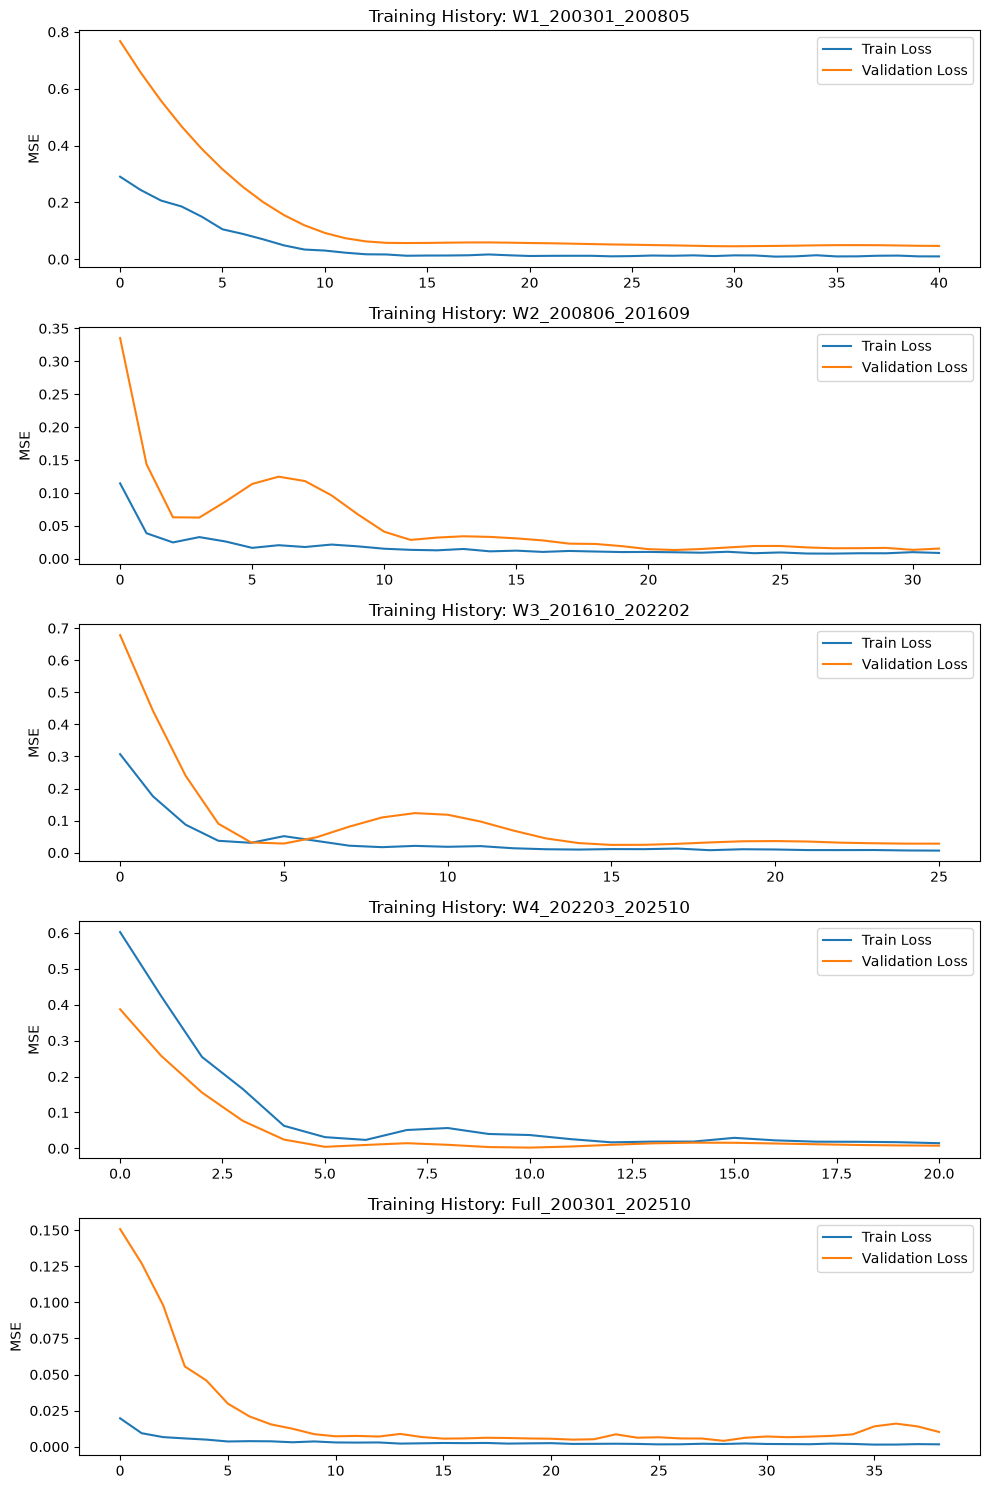

In [22]:
fig, axes = plt.subplots(len(WINDOWS), 1, figsize=(10, 3 * len(WINDOWS)), sharex=False)
for ax, (label, r) in zip(axes, results.items()):
    ax.plot(r["history"].history["loss"], label="Train Loss")
    ax.plot(r["history"].history["val_loss"], label="Validation Loss")
    ax.set_title(f"Training History: {label}")
    ax.set_ylabel("MSE")
    ax.legend()
plt.tight_layout()
plt.show()

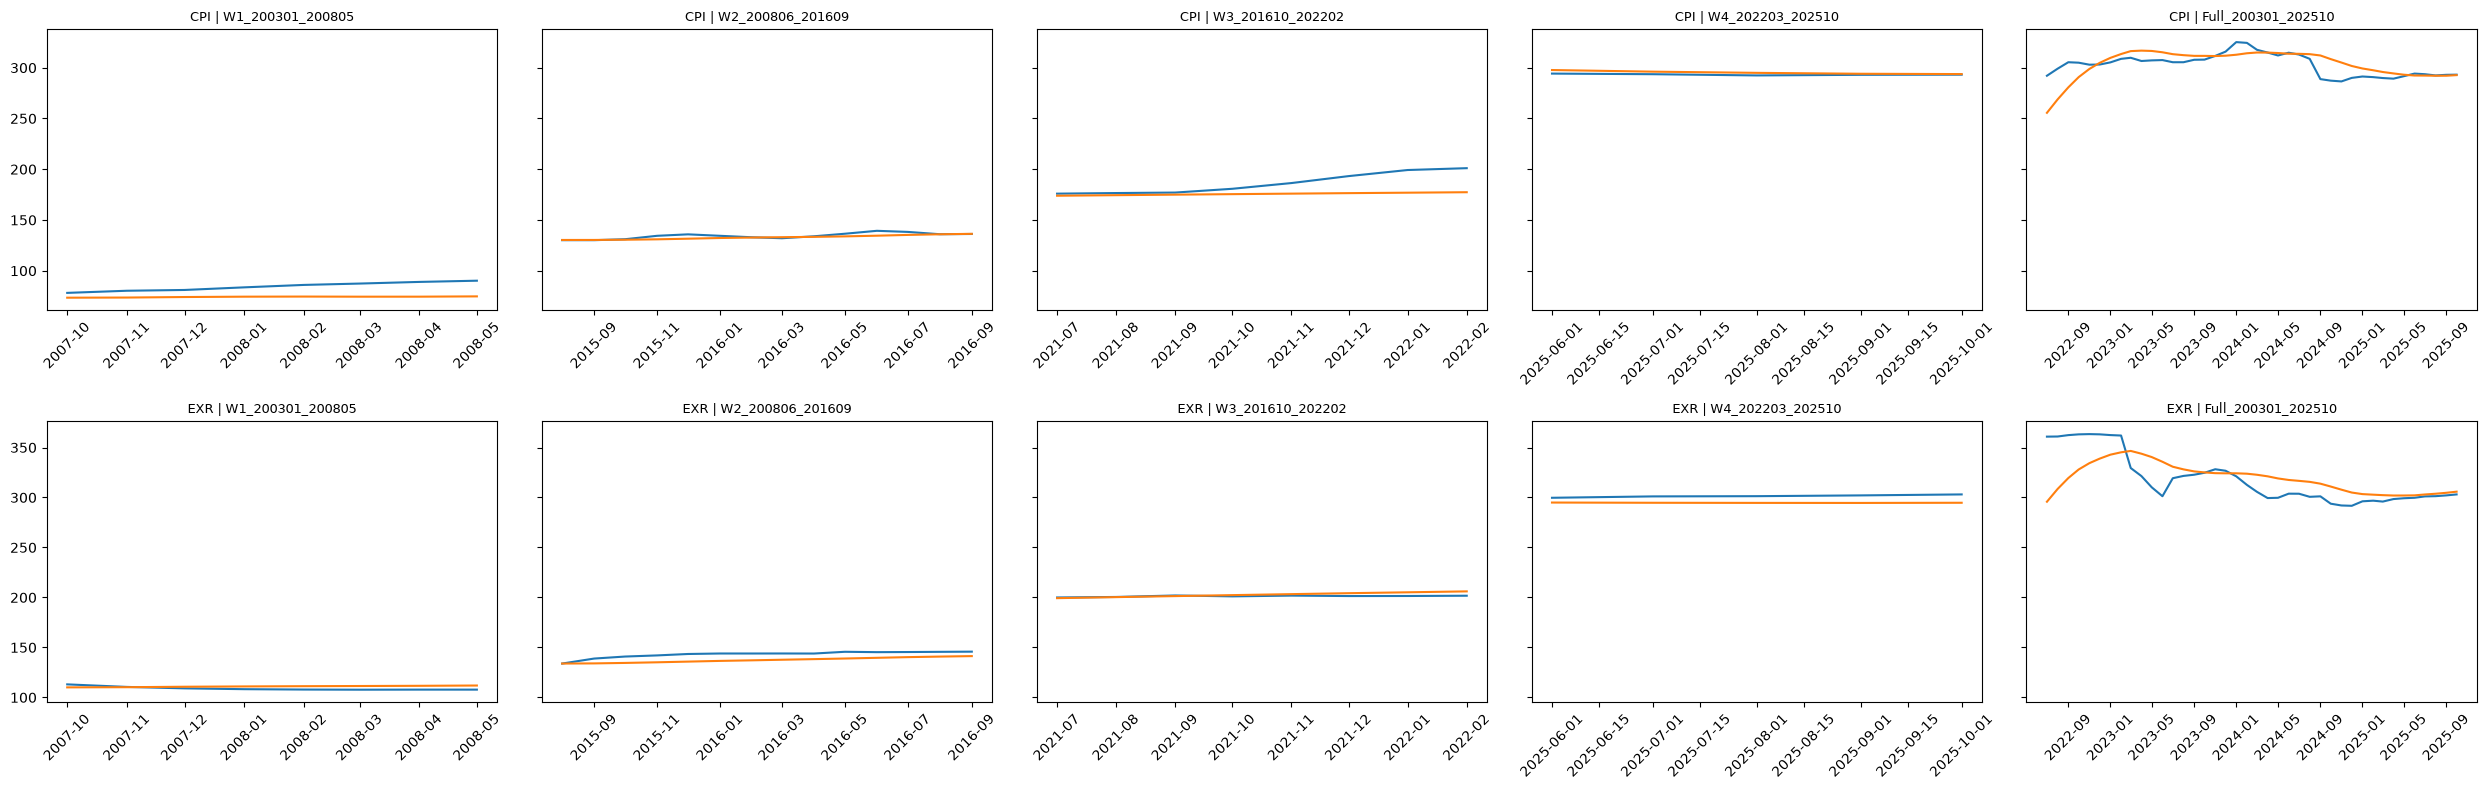

In [23]:
fig, axes = plt.subplots(len(TARGET_COLS), len(WINDOWS), figsize=(5 * len(WINDOWS), 4 * len(TARGET_COLS)), sharey="row")
for col_idx, target in enumerate(TARGET_COLS):
    for win_idx, (label, r) in enumerate(results.items()):
        ax = axes[col_idx, win_idx]
        ax.plot(r["test_dates"], r["test_actual"][:, col_idx], label="Actual")
        ax.plot(r["test_dates"], r["test_preds"][:, col_idx], label="Predicted")
        ax.set_title(f"{target} | {label}", fontsize=9)
        ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

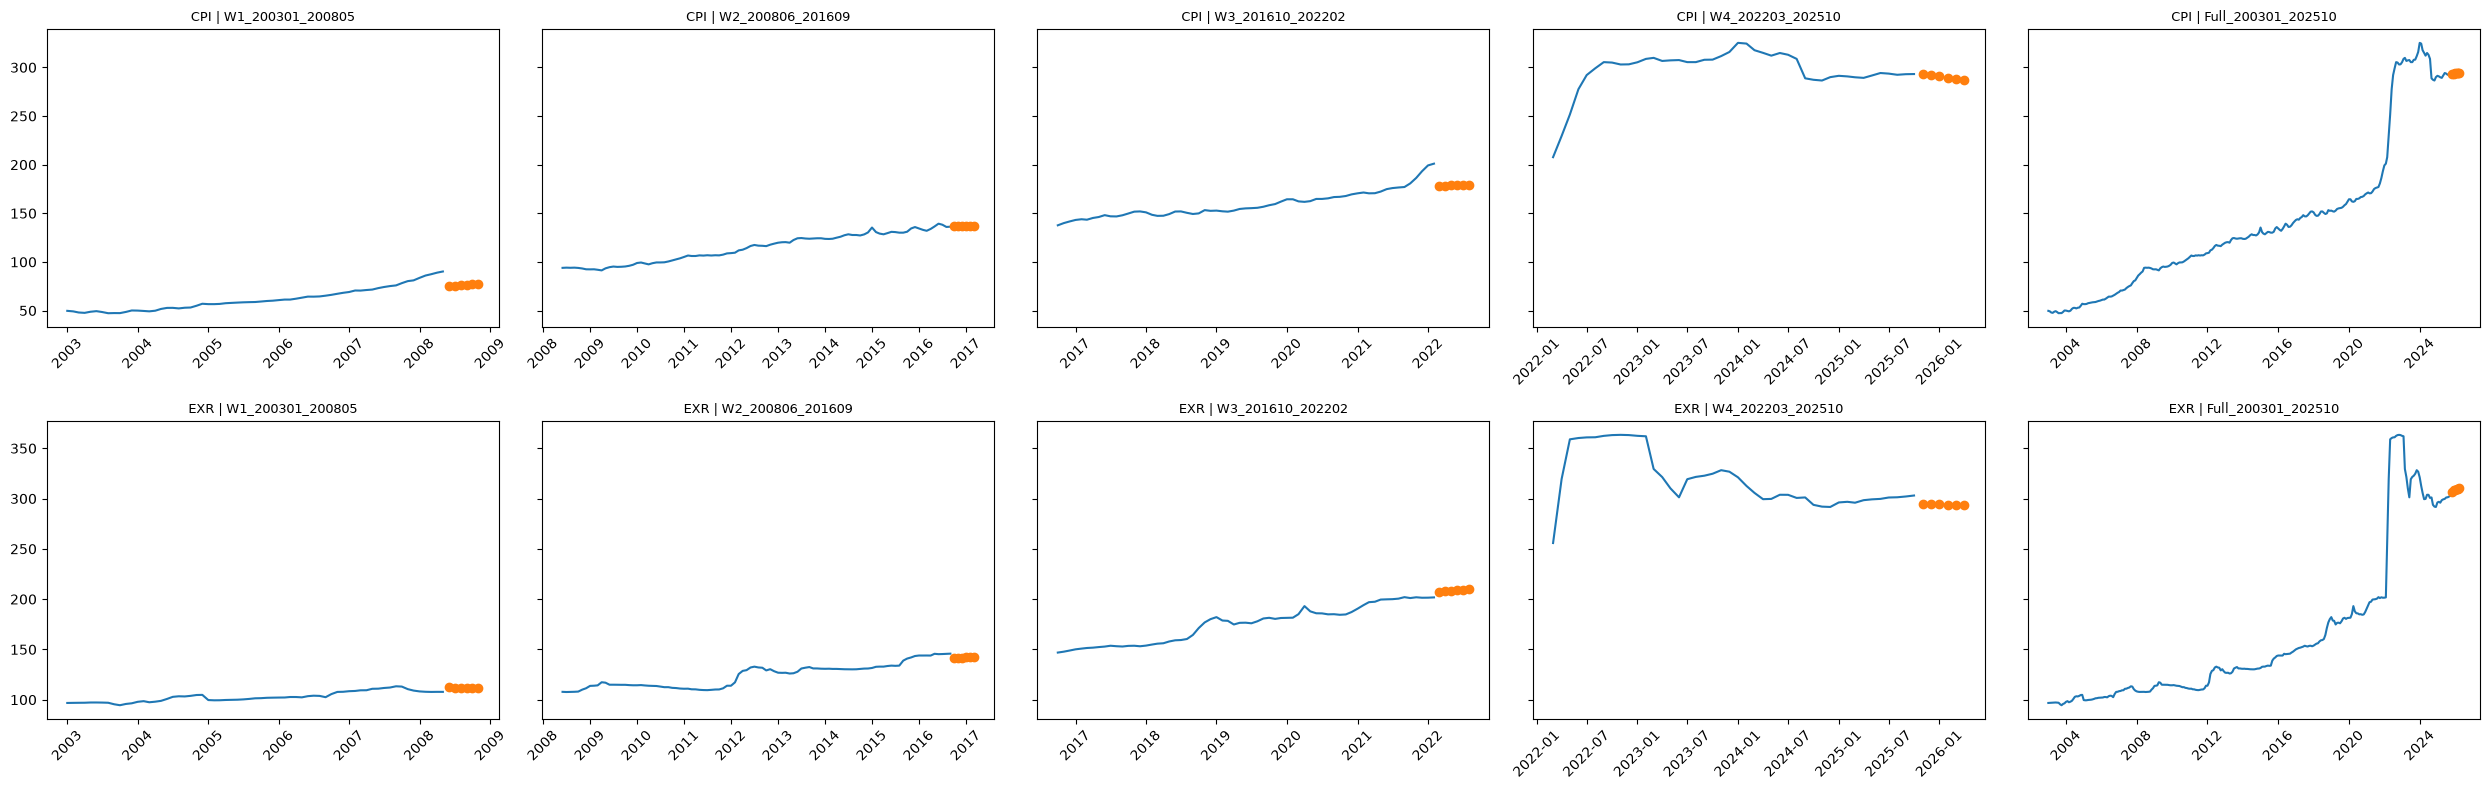

In [24]:
fig, axes = plt.subplots(len(TARGET_COLS), len(WINDOWS), figsize=(5 * len(WINDOWS), 4 * len(TARGET_COLS)), sharey="row")
for col_idx, target in enumerate(TARGET_COLS):
    for win_idx, (label, r) in enumerate(results.items()):
        ax = axes[col_idx, win_idx]
        ax.plot(r["df_window"].index, r["df_window"][target], label="History")
        ax.plot(r["forecast_df"].index, r["forecast_df"][target], linestyle="--", marker="o", label="Forecast")
        ax.set_title(f"{target} | {label}", fontsize=9)
        ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

In [25]:
os.makedirs("../results", exist_ok=True)
# Standardized long-format export consumed by the model-comparison pipeline.
canon_labels = [f"W{i + 1}" for i in range(len(results))]
export_rows = [
    {"window": canon, "target": col, "RMSE": r["metrics"][col]["RMSE"], "MAE": r["metrics"][col]["MAE"]}
    for canon, (label, r) in zip(canon_labels, results.items()) for col in TARGET_COLS
]
pd.DataFrame(export_rows).to_csv(f"../results/metrics_lstm.csv", index=False)

In [26]:
canon_labels = [f"W{i + 1}" for i in range(len(results))]
pred_rows = [
    {"window": canon, "target": col, "date": date,
     "actual": r["test_actual"][i, j], "predicted": r["test_preds"][i, j]}
    for canon, (label, r) in zip(canon_labels, results.items())
    for i, date in enumerate(r["test_dates"])
    for j, col in enumerate(TARGET_COLS)
]
pd.DataFrame(pred_rows).to_csv("../results/predictions_lstm.csv", index=False)